In [1]:
!pip install pymannkendall

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd, numpy as np, pymannkendall as mk
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')
TEMP_DIR   = r"C:\Users\Apechhya Aryal\Desktop\forpaper\TEMPRATURE_CORRECTED"
OUTPUT_DIR = r"C:\Users\Apechhya Aryal\Desktop\forpaper\trend_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

STATIONS = {
    'Jomsom':{'lat':28.78401,'lon':83.72982,'elev':2741},
    'Thakmarpha':{'lat':28.73887,'lon':83.68183,'elev':2655},
    'Lete':{'lat':28.63273,'lon':83.60922,'elev':2490},
    'Ranipauwa':{'lat':28.81556,'lon':83.86222,'elev':3671},
    'Samar_Gaun':{'lat':28.96202,'lon':83.80163,'elev':3610},
    'Dhakarjhong':{'lat':28.82359,'lon':83.73951,'elev':3200},
    'Chhoser':{'lat':29.22713,'lon':83.97982,'elev':3886},
}

def pettitt_test(series):
    """Pettitt (1979) non-parametric change-point. Valid for (approximately) independent
    data - use on ANNUAL series, not on overlapping rolling accumulations."""
    x = np.asarray(series.values, float); n = len(x)
    U = np.zeros(n)
    for t in range(n):
        U[t] = np.sum(np.sign(x[t] - x))
    S = np.cumsum(U); K = np.max(np.abs(S)); tc = int(np.argmax(np.abs(S)))
    p = min(2*np.exp(-6*K**2/(n**3 + n**2)), 1.0)
    return tc, K, p

def sig_stars(p):
    return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
print("Ready!")

Ready!


## 3.1 Load Annual Temperature + Run Hamed-Rao MK

In [3]:
station_annual = {}
for s in STATIONS:
    tdf=pd.read_csv(os.path.join(TEMP_DIR,f'{s}_temp_corrected.csv'))
    tdf['Date']=pd.to_datetime(tdf['Date']); tdf=tdf.set_index('Date')
    annual=tdf[['Tmax','Tmin','Tavg']].resample('YE').mean(); annual.index=annual.index.year
    station_annual[s]=annual

district = pd.concat([station_annual[s] for s in STATIONS]).groupby(level=0).mean()
district.to_csv(os.path.join(OUTPUT_DIR,'district_annual_temperature.csv'))

mk_results = []
print('District Mann-Kendall (Hamed-Rao corrected):')
for v in ['Tmax','Tmin','Tavg']:
    res = mk.hamed_rao_modification_test(district[v].dropna())
    ac1 = district[v].autocorr(lag=1)
    mk_results.append({'Variable':v,'Slope_per_decade':round(res.slope*10,3),
        'Lag1_AC':round(ac1,3),'HamedRao_p':round(res.p,5),'Significance':sig_stars(res.p)})
    print(f'  {v}: {res.slope*10:+.3f} degC/dec, AC1={ac1:.3f}, p={res.p:.5f} {sig_stars(res.p)}')

for s in STATIONS:
    res=mk.hamed_rao_modification_test(station_annual[s]['Tavg'].dropna())
    mk_results.append({'Variable':f'Tavg_{s}','Slope_per_decade':round(res.slope*10,3),
        'Lag1_AC':round(station_annual[s]['Tavg'].autocorr(lag=1),3),
        'HamedRao_p':round(res.p,5),'Significance':sig_stars(res.p)})

pd.DataFrame(mk_results).to_csv(os.path.join(OUTPUT_DIR,'mann_kendall_results.csv'),index=False)
display(pd.DataFrame(mk_results))

District Mann-Kendall (Hamed-Rao corrected):
  Tmax: +0.563 degC/dec, AC1=0.624, p=0.00001 ***
  Tmin: +0.271 degC/dec, AC1=0.406, p=0.00567 **
  Tavg: +0.426 degC/dec, AC1=0.445, p=0.00000 ***


,Variable,Slope_per_decade,Lag1_AC,HamedRao_p,Significance
0,Tmax,0.563,0.624,0.00001,***
1,Tmin,0.271,0.406,0.00567,**
2,Tavg,0.426,0.445,0.00000,***
3,Tavg_Jomsom,0.324,0.293,0.00147,**
4,Tavg_Thakmarpha,0.287,0.381,0.02243,*
5,Tavg_Lete,0.319,0.373,0.00108,**
6,Tavg_Ranipauwa,0.578,0.535,0.00000,***
7,Tavg_Samar_Gaun,0.579,0.535,0.00000,***
8,Tavg_Dhakarjhong,0.323,0.293,0.00147,**
9,Tavg_Chhoser,0.578,0.535,0.00000,***


## 3.2 Pettitt Change-Point Analysis (annual series)

In [4]:
cp_results = []
print('Pettitt change-points (annual):')
for label, series in [('Tmax',district['Tmax']),('Tmin',district['Tmin']),('Tavg',district['Tavg'])]:
    sc=series.dropna(); tc,K,p=pettitt_test(sc); cp=int(sc.index[tc])
    before=sc.iloc[:tc+1].mean(); after=sc.iloc[tc+1:].mean()
    cp_results.append({'Variable':label,'ChangePoint':cp,'p':round(p,5),'Sig':sig_stars(p),
        'Before':round(before,3),'After':round(after,3),'Shift':round(after-before,3)})
    print(f'  {label}: cp={cp}, shift={after-before:+.3f} degC, p={p:.5f} {sig_stars(p)}')

cp_df = pd.DataFrame(cp_results)
cp_df.to_csv(os.path.join(OUTPUT_DIR,'pettitt_changepoint.csv'),index=False)

# Report the temporal ORDER of the detected change-points (data-driven, not hardcoded).
ordered = cp_df.sort_values('ChangePoint')[['Variable','ChangePoint','Sig']]
print('\nDetected temporal sequence of change-points (timing only, not causal):')
print('  ' + '  ->  '.join(f"{r.Variable} ({r.ChangePoint}, {r.Sig})" for r in ordered.itertuples()))
print('  (Compare with the SPEI-12 change-point from Notebook 4 when interpreting.)')

Pettitt change-points (annual):
  Tmax: cp=2003, shift=+1.235 degC, p=0.00143 **
  Tmin: cp=1994, shift=+0.726 degC, p=0.00845 **
  Tavg: cp=1997, shift=+0.814 degC, p=0.00064 ***

Detected temporal sequence of change-points (timing only, not causal):
  Tmin (1994, **)  ->  Tavg (1997, ***)  ->  Tmax (2003, **)
  (Compare with the SPEI-12 change-point from Notebook 4 when interpreting.)


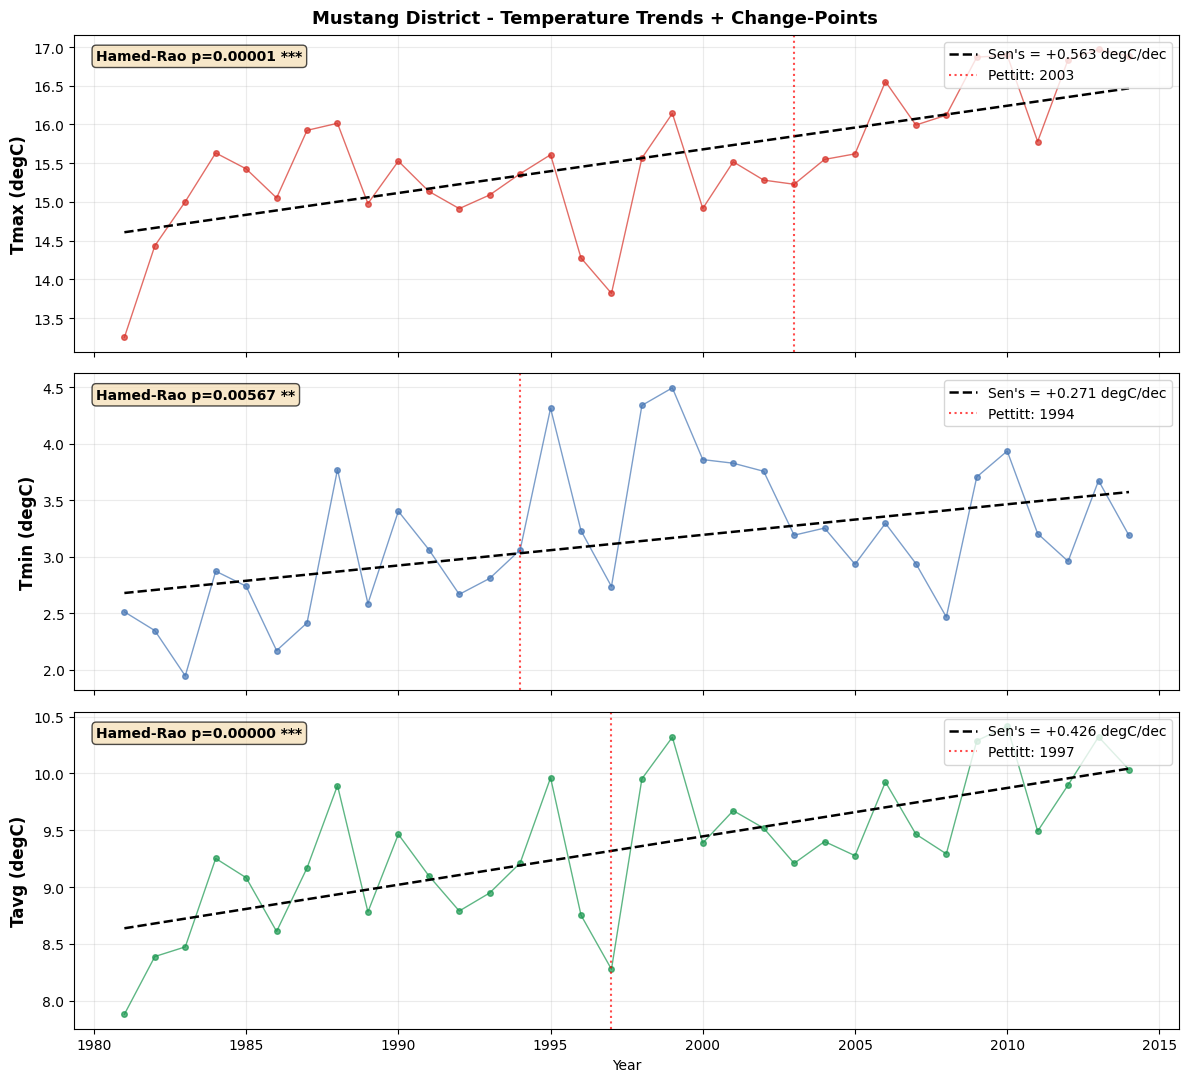

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
years = district.index.values
for ax, var, color in zip(axes, ['Tmax','Tmin','Tavg'], ['#d73027','#4575b4','#1a9850']):
    series=district[var]
    ax.plot(years,series.values,'o-',color=color,markersize=4,linewidth=1,alpha=0.7)
    res=mk.hamed_rao_modification_test(series.dropna())
    trend_line=res.intercept+res.slope*np.arange(len(years))
    ax.plot(years,trend_line,'--',color='black',linewidth=1.8,label=f"Sen's = {res.slope*10:+.3f} degC/dec")
    ax.text(0.02,0.92,f'Hamed-Rao p={res.p:.5f} {sig_stars(res.p)}',transform=ax.transAxes,fontsize=10,
            fontweight='bold',bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.7))
    tc,_,_=pettitt_test(series.dropna()); cp=int(series.dropna().index[tc])
    ax.axvline(cp,color='red',linestyle=':',linewidth=1.5,alpha=0.7,label=f'Pettitt: {cp}')
    ax.set_ylabel(f'{var} (degC)',fontsize=12,fontweight='bold'); ax.legend(loc='upper right'); ax.grid(True,alpha=0.25)
axes[-1].set_xlabel('Year')
plt.suptitle('Mustang District - Temperature Trends + Change-Points',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'district_trends.png'),dpi=300,bbox_inches='tight'); plt.show()